# Universal EEG ADHD — Robust CNN + Transformer Colab

### What this notebook does
- Accepts a **ZIP, MAT, CSV, EDF, FIF, SET, NPY or NPZ** EEG dataset.
- Recursively discovers EEG recordings.
- Handles different numbers of EEG channels.
- Detects labels from a metadata CSV when available, otherwise from folder/file names.
- Detects subject IDs from metadata/path/file name.
- Reads common EEG formats.
- Uses the sampling rate stored in the file when available; otherwise uses the value you explicitly set.
- Resamples all recordings to one training frequency.
- Band-pass filters, notch-filters, normalizes, and windows EEG.
- Uses **subject-wise splitting** to prevent leakage.
- Trains an **EEG CNN + Transformer** model.
- Also trains a frequency-feature XGBoost baseline.
- Tunes the decision threshold on validation data only.
- Reports subject-level Accuracy, Balanced Accuracy, Precision, Recall, Specificity, F1, ROC-AUC, PR-AUC, MCC and a confusion matrix.
- Saves the trained model and preprocessing metadata.

### Important
No notebook can guarantee 100% correct predictions or accept literally every EEG dataset without metadata. EEG datasets differ in labels, sampling rates, channel conventions and file structures. This notebook is designed to **stop with a clear instruction when it cannot safely infer something**, instead of silently creating wrong labels.

**Research prototype — not a clinical diagnostic system.**

In [2]:
# Colab setup
!pip -q install numpy pandas scipy scikit-learn matplotlib seaborn joblib xgboost mne h5py

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 19.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.


In [3]:
import os, re, json, math, shutil, zipfile, warnings, tempfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from scipy import signal
import scipy.io as sio

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    matthews_corrcoef, classification_report, roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import mne

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: []


## 1. Dataset settings

Usually you only need to change `DATASET_PATH` after uploading.

If automatic label detection fails, set:
- `LABEL_MAP` for folder/file labels, and/or
- `METADATA_CSV` if your dataset has a metadata table, and/or
- `DEFAULT_FS` when the EEG file itself does not store its sampling rate.

Example:
```python
LABEL_MAP = {
    "adhd": 1,
    "control": 0,
    "healthy": 0
}
```

For a different binary EEG problem, change `CLASS_NAMES` and the label map accordingly.

In [4]:
# Upload one dataset file. ZIP is recommended when your dataset contains many folders/files.
from google.colab import files

uploaded = files.upload()
if not uploaded:
    raise RuntimeError("No dataset uploaded.")

UPLOADED = Path("/content") / next(iter(uploaded.keys()))
print("Uploaded:", UPLOADED)

Saving ADHD_EEG_19ch_128Hz_Colab_Ready.zip to ADHD_EEG_19ch_128Hz_Colab_Ready (1).zip
Uploaded: /content/ADHD_EEG_19ch_128Hz_Colab_Ready (1).zip


In [5]:
# --------- USER CONFIGURATION ---------

DATASET_PATH = UPLOADED

# If a metadata CSV exists inside the uploaded ZIP, leave this as None.
# The notebook will search for likely metadata files.
METADATA_CSV = None

# Label mapping. Use lowercase names/keywords.
# Add aliases used by your dataset. Examples:
# Label mapping for this dataset
LABEL_MAP = {
    "adhd": 1,
    "control": 0,
    "healthy": 0,
    "hc": 0,
    "normal": 0,
    "nonadhd": 0,
    "non-adhd": 0
}

CLASS_NAMES = {
    0: "Control",
    1: "ADHD"
}

# If a file contains no sampling-rate metadata, set this explicitly.
# 128 is correct for your current 121-subject dataset.
DEFAULT_FS = 128.0

# Signal preprocessing
TARGET_FS = 128.0
LOWCUT = 1.0
HIGHCUT = 45.0
NOTCH_HZ = 50.0

# Windowing
WINDOW_SECONDS = 10
OVERLAP = 0.50
MIN_RECORDING_SECONDS = 5

# Training
EPOCHS = 35
BATCH_SIZE = 32
PATIENCE = 7
DROPOUT = 0.25

# Test/validation split is by SUBJECT, never by individual windows.
TEST_FRACTION = 0.20
VAL_FRACTION_OF_REMAINING = 0.20

# Set False only if your dataset has already been carefully preprocessed.
APPLY_NOTCH = True

OUTPUT_DIR = Path("/content/eeg_adhd_model_package")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Configuration ready.")

Configuration ready.


In [6]:
# ---------- Extract ZIP / discover files ----------
RAW_DIR = Path("/content/eeg_dataset")
if RAW_DIR.exists():
    shutil.rmtree(RAW_DIR)
RAW_DIR.mkdir(parents=True)

if DATASET_PATH.suffix.lower() == ".zip":
    with zipfile.ZipFile(DATASET_PATH, "r") as z:
        z.extractall(RAW_DIR)
    ROOT = RAW_DIR
else:
    ROOT = DATASET_PATH.parent

SUPPORTED = {".mat", ".csv", ".edf", ".fif", ".set", ".npy", ".npz"}

EEG_FILES = sorted({
    p for p in ROOT.rglob("*")
    if p.is_file() and p.suffix.lower() in SUPPORTED
})

print("Root:", ROOT)
print("EEG-like files found:", len(EEG_FILES))
for p in EEG_FILES[:30]:
    print(" ", p.relative_to(ROOT))
if not EEG_FILES:
    raise RuntimeError(
        "No supported EEG recordings found. Supported: MAT, CSV, EDF, FIF, SET, NPY, NPZ."
    )

Root: /content/eeg_dataset
EEG-like files found: 122
  ADHD/v10p.mat
  ADHD/v12p.mat
  ADHD/v14p.mat
  ADHD/v15p.mat
  ADHD/v173.mat
  ADHD/v177.mat
  ADHD/v179.mat
  ADHD/v181.mat
  ADHD/v183.mat
  ADHD/v18p.mat
  ADHD/v190.mat
  ADHD/v196.mat
  ADHD/v198.mat
  ADHD/v19p.mat
  ADHD/v1p.mat
  ADHD/v200.mat
  ADHD/v204.mat
  ADHD/v206.mat
  ADHD/v209.mat
  ADHD/v20p.mat
  ADHD/v213.mat
  ADHD/v215.mat
  ADHD/v219.mat
  ADHD/v21p.mat
  ADHD/v227.mat
  ADHD/v22p.mat
  ADHD/v231.mat
  ADHD/v234.mat
  ADHD/v236.mat
  ADHD/v238.mat


In [7]:
# ---------- Metadata discovery ----------
def find_metadata_csv(root):
    candidates = []
    for p in root.rglob("*.csv"):
        name = p.name.lower()
        if any(k in name for k in ["metadata", "labels", "participants", "subjects", "demographic", "clinical"]):
            candidates.append(p)
    return candidates[0] if candidates else None

META_PATH = Path(METADATA_CSV) if METADATA_CSV else find_metadata_csv(ROOT)

if META_PATH and META_PATH.exists():
    META = pd.read_csv(META_PATH)
    print("Metadata:", META_PATH)
    print("Columns:", list(META.columns))
    display(META.head())
else:
    META = None
    print("No obvious metadata CSV found. Labels will be inferred from paths/file names.")

Metadata: /content/eeg_dataset/metadata.csv
Columns: ['subject_id', 'label', 'class', 'file']


,subject_id,label,class,file
0,v10p,1,ADHD,ADHD/v10p.mat
1,v12p,1,ADHD,ADHD/v12p.mat
2,v14p,1,ADHD,ADHD/v14p.mat
3,v15p,1,ADHD,ADHD/v15p.mat
4,v173,1,ADHD,ADHD/v173.mat


In [8]:
# ---------- Label + subject helpers ----------
def normalize_text(x):
    return re.sub(r"[^a-z0-9]+", "", str(x).lower())

def infer_label_from_text(text):
    """
    Detect ADHD/Control from folder name or file path.
    """
    path = Path(str(text))

    # Check folder names first
    for part in path.parts:
        folder = str(part).strip().lower()

        if folder == "adhd":
            return 1

        if folder in {"control", "healthy", "hc", "normal", "nonadhd", "non-adhd"}:
            return 0

    # Then check the complete path using LABEL_MAP
    t = str(text).lower()

    matches = []

    for alias, lab in LABEL_MAP.items():
        if re.search(
            r"(?<![a-z0-9])" +
            re.escape(alias.lower()) +
            r"(?![a-z0-9])",
            t
        ):
            matches.append(int(lab))

    if len(set(matches)) == 1:
        return matches[0]

    if len(set(matches)) > 1:
        raise ValueError(
            f"Conflicting labels found in path: {text}"
        )

    return None

def infer_subject_from_path(path):
    p = Path(path)
    # First try common subject/participant identifiers.
    for part in [p.stem] + list(p.parts[::-1]):
        m = re.search(r"(?:subject|sub|participant|patient|case)[-_ ]?([A-Za-z0-9]+)", part, re.I)
        if m:
            return m.group(1)
    # If folder contains a class name, use the recording stem as subject.
    # This is conservative: each file becomes its own subject unless a subject token is visible.
    return p.stem

def metadata_row_for_file(path):
    if META is None:
        return None
    cols = {str(c).lower().strip(): c for c in META.columns}
    file_col = next((cols[k] for k in ["file","filename","filepath","path","recording"] if k in cols), None)
    if file_col is None:
        return None
    target = Path(str(path)).name.lower()
    matches = META[META[file_col].astype(str).str.lower().map(lambda x: Path(x).name == target)]
    if len(matches):
        return matches.iloc[0]
    return None

def label_from_metadata(row):
    if row is None:
        return None
    cols = {str(c).lower().strip(): c for c in row.index}
    for key in ["label","class","target","condition","group","diagnosis","diagnosis_label"]:
        if key in cols:
            v = row[cols[key]]
            if pd.isna(v):
                continue
            if str(v).strip().lower() in {"0","control","healthy","normal","hc"}:
                return 0
            if str(v).strip().lower() in {"1","adhd","patient","case"}:
                return 1
            try:
                iv = int(float(v))
                if iv in [0,1]:
                    return iv
            except:
                pass
            return infer_label_from_text(str(v))
    return None

def subject_from_metadata(row):
    if row is None:
        return None
    cols = {str(c).lower().strip(): c for c in row.index}
    for key in ["subject","subject_id","participant","participant_id","patient","patient_id","id"]:
        if key in cols and not pd.isna(row[cols[key]]):
            return str(row[cols[key]])
    return None

In [9]:
# ---------- Inspect dataset before training ----------
manifest = []

for p in EEG_FILES:
    row = metadata_row_for_file(p)
    label = label_from_metadata(row)
    if label is None:
        label = infer_label_from_text(str(p))

    subject = subject_from_metadata(row)
    if subject is None:
        subject = infer_subject_from_path(p)

    manifest.append({
        "file": str(p),
        "relative_file": str(p.relative_to(ROOT)),
        "label": label,
        "subject": str(subject)
    })

manifest = pd.DataFrame(manifest)

# Filter out the metadata CSV itself if it was included in EEG_FILES.
# This can happen if the metadata CSV has a supported extension like .csv.
if META_PATH and not META.empty: # Check if META_PATH exists and META was loaded successfully
    manifest = manifest[manifest["file"] != str(META_PATH)]

print("Total recordings:", len(manifest))
print("Missing labels:", int(manifest["label"].isna().sum()))
print("Labels:", manifest["label"].value_counts(dropna=False).to_dict())
print("Subjects:", manifest["subject"].nunique())

display(manifest.head(30))

if manifest["label"].isna().any():
    bad = manifest[manifest["label"].isna()].head(20)
    print("\nThese recordings have no reliable label:")
    display(bad)
    raise RuntimeError(
        "Cannot safely train because some recordings have no labels. "
        "Add the correct label aliases in LABEL_MAP or provide a metadata CSV."
    )

if manifest["label"].nunique() != 2:
    raise RuntimeError(
        "This notebook expects exactly two classes for binary ADHD vs Control classification. "
        f"Detected labels: {sorted(manifest['label'].unique().tolist())}"
    )

Total recordings: 121
Missing labels: 0
Labels: {1.0: 61, 0.0: 60}
Subjects: 121


,file,relative_file,label,subject
0,/content/eeg_dataset/ADHD/v10p.mat,ADHD/v10p.mat,1.0,v10p
1,/content/eeg_dataset/ADHD/v12p.mat,ADHD/v12p.mat,1.0,v12p
2,/content/eeg_dataset/ADHD/v14p.mat,ADHD/v14p.mat,1.0,v14p
3,/content/eeg_dataset/ADHD/v15p.mat,ADHD/v15p.mat,1.0,v15p
4,/content/eeg_dataset/ADHD/v173.mat,ADHD/v173.mat,1.0,v173
5,/content/eeg_dataset/ADHD/v177.mat,ADHD/v177.mat,1.0,v177
6,/content/eeg_dataset/ADHD/v179.mat,ADHD/v179.mat,1.0,v179
7,/content/eeg_dataset/ADHD/v181.mat,ADHD/v181.mat,1.0,v181
8,/content/eeg_dataset/ADHD/v183.mat,ADHD/v183.mat,1.0,v183
9,/content/eeg_dataset/ADHD/v18p.mat,ADHD/v18p.mat,1.0,v18p


## 2. EEG readers

The reader tries to handle common dataset structures:
- MATLAB `.mat`
- CSV
- EDF
- MNE `.fif`
- EEGLAB `.set`
- NumPy `.npy`
- NumPy `.npz`

For MAT/CSV/NPY/NPZ files, the code searches for a 2-D numeric signal matrix and chooses a plausible EEG matrix. If the file has an unusual structure, the notebook stops rather than silently using the wrong array.

In [10]:
# ---------- Generic matrix helpers ----------
def numeric_matrices(obj, prefix="root"):
    out = []
    if isinstance(obj, np.ndarray) and np.issubdtype(obj.dtype, np.number):
        if obj.ndim == 2 and min(obj.shape) >= 2:
            out.append((prefix, obj))
    elif isinstance(obj, dict):
        for k, v in obj.items():
            if not str(k).startswith("__"):
                out.extend(numeric_matrices(v, f"{prefix}.{k}"))
    elif hasattr(obj, "_fieldnames"):
        for k in obj._fieldnames:
            out.extend(numeric_matrices(getattr(obj, k), f"{prefix}.{k}"))
    elif isinstance(obj, (list, tuple)):
        for i, v in enumerate(obj):
            out.extend(numeric_matrices(v, f"{prefix}[{i}]"))
    return out

def choose_eeg_matrix(candidates):
    if not candidates:
        raise ValueError("No 2-D numeric matrix found.")
    scored = []
    common_channels = [4, 6, 8, 14, 16, 18, 19, 21, 24, 32, 64, 128, 256]
    for name, arr in candidates:
        r, c = arr.shape
        score = math.log1p(arr.size)
        if r >= 100 and c <= 256:
            score += 20
        if c in common_channels:
            score += 15
        if r in common_channels:
            score += 15
        if r > c:
            score += 10
        scored.append((score, name, arr))
    _, name, arr = max(scored, key=lambda x: x[0])
    return np.asarray(arr, dtype=np.float64), name

def read_mat(path):
    # Try standard MAT first.
    try:
        d = sio.loadmat(path, squeeze_me=True, struct_as_record=False)
        arr, src = choose_eeg_matrix(numeric_matrices(d))
        return arr, None, None, {"source": src}
    except Exception:
        # v7.3/HDF5 MAT
        import h5py
        with h5py.File(path, "r") as f:
            found = []
            def visit(name, obj):
                if hasattr(obj, "shape") and len(obj.shape) == 2 and np.issubdtype(obj.dtype, np.number):
                    found.append((name, np.array(obj)))
            f.visititems(visit)
            arr, src = choose_eeg_matrix(found)
            return arr, None, None, {"source": src}

def read_csv_file(path):
    df = pd.read_csv(path)
    numeric = df.select_dtypes(include=[np.number]).copy()
    if numeric.shape[1] < 2:
        raise ValueError("CSV has fewer than 2 numeric columns.")
    drop = []
    for c in numeric.columns:
        n = str(c).strip().lower()
        if n in {"time","timestamp","seconds","sec","sample","index","label","class","target","subject","id","age"}:
            drop.append(c)
    sig = numeric.drop(columns=drop, errors="ignore")
    if sig.shape[1] < 2:
        sig = numeric
    return sig.to_numpy(np.float64), [str(c) for c in sig.columns], None, {"source":"csv"}

def read_numpy_file(path):
    if path.suffix.lower() == ".npy":
        obj = np.load(path, allow_pickle=True)
        arr = np.asarray(obj)
        return choose_eeg_matrix(numeric_matrices(arr))[0], None, None, {"source":"npy"}
    data = np.load(path, allow_pickle=True)
    candidates = []
    for k in data.files:
        a = np.asarray(data[k])
        if a.ndim == 2 and np.issubdtype(a.dtype, np.number):
            candidates.append((k, a))
    arr, src = choose_eeg_matrix(candidates)
    return arr, None, None, {"source":src}

def read_mne_file(path):
    ext = path.suffix.lower()
    if ext == ".edf":
        raw = mne.io.read_raw_edf(path, preload=True, verbose="ERROR")
    elif ext == ".fif":
        raw = mne.io.read_raw_fif(path, preload=True, verbose="ERROR")
    elif ext == ".set":
        raw = mne.io.read_raw_eeglab(path, preload=True, verbose="ERROR")
    else:
        raise ValueError(ext)
    picks = mne.pick_types(raw.info, eeg=True, exclude="bads")
    if len(picks) < 2:
        raise ValueError("Fewer than two usable EEG channels.")
    return raw.get_data(picks=picks).T.astype(np.float64), [raw.ch_names[i] for i in picks], float(raw.info["sfreq"]), {"source":ext}

def read_recording(path):
    ext = path.suffix.lower()
    if ext == ".mat": return read_mat(path)
    if ext == ".csv": return read_csv_file(path)
    if ext in {".edf",".fif",".set"}: return read_mne_file(path)
    if ext in {".npy",".npz"}: return read_numpy_file(path)
    raise ValueError(f"Unsupported extension: {ext}")

In [11]:
# ---------- Orientation, sampling rate and preprocessing ----------
def orient_time_channels(arr, channel_names=None):
    arr = np.asarray(arr, dtype=np.float64)
    if arr.ndim != 2:
        raise ValueError(f"Expected 2-D signal, got {arr.shape}")

    if channel_names is not None and len(channel_names) in arr.shape:
        if arr.shape[1] != len(channel_names):
            arr = arr.T
    elif arr.shape[0] < arr.shape[1]:
        arr = arr.T

    return arr

def resample_signal(x, fs, target_fs):
    if abs(fs - target_fs) < 1e-6:
        return x, fs
    from scipy.signal import resample_poly
    g = math.gcd(int(round(fs)), int(round(target_fs)))
    up = int(round(target_fs)) // g
    down = int(round(fs)) // g
    y = resample_poly(x, up, down, axis=0)
    return y, target_fs

def preprocess_signal(x, fs):
    x = np.asarray(x, dtype=np.float64)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    if fs <= 2 * HIGHCUT:
        # Keep the upper cutoff safely below Nyquist.
        high = min(HIGHCUT, fs * 0.45)
    else:
        high = HIGHCUT

    low = min(LOWCUT, high * 0.5)
    if high <= low:
        raise ValueError(f"Invalid band for fs={fs}: low={low}, high={high}")

    sos = signal.butter(4, [low, high], btype="bandpass", fs=fs, output="sos")
    x = signal.sosfiltfilt(sos, x, axis=0)

    if APPLY_NOTCH and NOTCH_HZ < fs/2:
        b, a = signal.iirnotch(NOTCH_HZ, Q=30, fs=fs)
        x = signal.filtfilt(b, a, x, axis=0)

    # Per-channel normalization.
    mu = np.mean(x, axis=0, keepdims=True)
    sd = np.std(x, axis=0, keepdims=True) + 1e-8
    x = (x - mu) / sd
    return x

def make_windows(x, fs):
    n = int(round(WINDOW_SECONDS * fs))
    step = max(1, int(round(n * (1 - OVERLAP))))
    if len(x) < n:
        return []
    return [x[i:i+n] for i in range(0, len(x)-n+1, step)]

In [12]:
# ---------- Read all recordings ----------
records = []
errors = []

for _, row in manifest.iterrows():
    p = Path(row["file"])
    try:
        arr, ch_names, fs, info = read_recording(p)
        arr = orient_time_channels(arr, ch_names)

        if fs is None:
            fs = DEFAULT_FS
        if fs is None:
            raise ValueError("Sampling rate is missing. Set DEFAULT_FS explicitly.")

        if arr.shape[0] / fs < MIN_RECORDING_SECONDS:
            raise ValueError("Recording is shorter than MIN_RECORDING_SECONDS.")

        arr, used_fs = resample_signal(arr, float(fs), TARGET_FS)
        arr = preprocess_signal(arr, used_fs)
        windows = make_windows(arr, used_fs)

        if not windows:
            raise ValueError("No complete windows after preprocessing.")

        records.append({
            "file": str(p),
            "subject": str(row["subject"]),
            "label": int(row["label"]),
            "fs": float(used_fs),
            "n_channels": int(arr.shape[1]),
            "channel_names": ch_names,
            "windows": windows
        })
    except Exception as e:
        errors.append({"file": str(p), "error": str(e)})

print("Usable recordings:", len(records))
print("Failed recordings:", len(errors))

if errors:
    print("\nFirst failures:")
    display(pd.DataFrame(errors).head(20))

if not records:
    raise RuntimeError("No recordings could be read. Inspect the failure table above.")

Usable recordings: 121
Failed recordings: 0


In [13]:
# ---------- Subject-wise split ----------
subject_table = (
    pd.DataFrame([{"subject":r["subject"], "label":r["label"]} for r in records])
    .drop_duplicates("subject")
    .reset_index(drop=True)
)

if subject_table["label"].value_counts().min() < 2:
    raise RuntimeError("Need at least 2 subjects in each class for a train/test split.")

# First split: train+validation vs test
sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
trainval_idx, test_idx = next(sgkf.split(
    subject_table, subject_table["label"], groups=subject_table["subject"]
))

trainval = subject_table.iloc[trainval_idx].copy()
test_subjects = set(subject_table.iloc[test_idx]["subject"])

# Second split: train vs validation
n_splits2 = 5
sgkf2 = StratifiedGroupKFold(n_splits=n_splits2, shuffle=True, random_state=SEED+1)
tr_idx, va_idx = next(sgkf2.split(
    trainval, trainval["label"], groups=trainval["subject"]
))

train_subjects = set(trainval.iloc[tr_idx]["subject"])
val_subjects = set(trainval.iloc[va_idx]["subject"])

print("Train subjects:", len(train_subjects))
print("Validation subjects:", len(val_subjects))
print("Test subjects:", len(test_subjects))

def build_window_arrays(subject_set):
    X, y, g = [], [], []
    for r in records:
        if r["subject"] not in subject_set:
            continue
        for w in r["windows"]:
            X.append(w)
            y.append(r["label"])
            g.append(r["subject"])
    return np.asarray(X, dtype=np.float32), np.asarray(y, dtype=np.int32), np.asarray(g)

X_train, y_train, g_train = build_window_arrays(train_subjects)
X_val, y_val, g_val = build_window_arrays(val_subjects)
X_test, y_test, g_test = build_window_arrays(test_subjects)

print("Window shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Class balance train:", Counter(y_train))

Train subjects: 77
Validation subjects: 20
Test subjects: 24
Window shapes: (2016, 1280, 19) (539, 1280, 19) (646, 1280, 19)
Class balance train: Counter({np.int32(1): 1116, np.int32(0): 900})


In [14]:
# ---------- Pad variable channel counts ----------
# The CNN expects one fixed number of channels for this training run.
# We preserve the actual channels and zero-pad datasets with fewer channels.
MAX_CHANNELS = max(X_train.shape[2], X_val.shape[2], X_test.shape[2])

def pad_channels(X, n_channels):
    if X.shape[2] == n_channels:
        return X
    if X.shape[2] > n_channels:
        return X[:, :, :n_channels]
    out = np.zeros((X.shape[0], X.shape[1], n_channels), dtype=np.float32)
    out[:, :, :X.shape[2]] = X
    return out

X_train = pad_channels(X_train, MAX_CHANNELS)
X_val = pad_channels(X_val, MAX_CHANNELS)
X_test = pad_channels(X_test, MAX_CHANNELS)

print("Final CNN input:", X_train.shape)

Final CNN input: (2016, 1280, 19)


## 3. Main model — CNN + Transformer

The CNN extracts local temporal EEG patterns. The Transformer then models relationships among the learned channel representations. The model is trained separately for the uploaded dataset, so it does not assume that every EEG dataset has exactly 19 channels.

In [15]:
# ---------- CNN + Transformer ----------
class PositionalEmbedding(layers.Layer):
    def __init__(self, max_len, d_model):
        super().__init__()
        self.pos = self.add_weight(
            shape=(1, max_len, d_model),
            initializer="random_normal",
            trainable=True
        )

    def call(self, x):
        return x + self.pos[:, :tf.shape(x)[1], :]

def transformer_block(x, d_model, heads, dropout):
    attn = layers.MultiHeadAttention(
        num_heads=heads,
        key_dim=d_model // heads,
        dropout=dropout
    )(x, x)
    x = layers.LayerNormalization()(x + attn)

    ff = layers.Dense(d_model * 2, activation="gelu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(d_model)(ff)

    return layers.LayerNormalization()(x + ff)

def build_model(input_shape):
    inp = keras.Input(shape=input_shape)

    # Temporal feature extraction
    x = layers.Conv1D(32, 7, padding="same")(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling1D(4)(x)

    x = layers.Conv1D(64, 5, padding="same")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)
    x = layers.MaxPooling1D(4)(x)

    # Project to transformer dimension
    x = layers.Conv1D(128, 3, padding="same")(x)

    # Keep a temporal sequence for attention
    x = PositionalEmbedding(1000, 128)(x)

    x = transformer_block(x, 128, 4, DROPOUT)
    x = transformer_block(x, 128, 4, DROPOUT)

    x = layers.GlobalAveragePooling1D()(x)
    x = layers.Dense(64, activation="gelu")(x)
    x = layers.Dropout(DROPOUT)(x)
    out = layers.Dense(1, activation="sigmoid")(x)

    return keras.Model(inp, out, name="EEG_CNN_Transformer")

model = build_model(X_train.shape[1:])
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)
model.summary()

Model: "EEG_CNN_Transformer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1280, 19)  │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 1280, 32)  │      4,288 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 1280, 32)  │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 1280, 32)  │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 320, 32)   │          0 │ activation[0][0]  │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 320, 64)   │     10,304 │ max_pooling1d[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 320, 64)   │        256 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 320, 64)   │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d_1     │ (None, 80, 64)    │          0 │ activation_1[0][… │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 80, 128)   │     24,704 │ max_pooling1d_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ positional_embeddi… │ (None, 80, 128)   │    128,000 │ conv1d_2[0][0]    │
│ (PositionalEmbeddi… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 80, 128)   │     66,048 │ positional_embed… │
│ (MultiHeadAttentio… │                   │            │ positional_embed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 80, 128)   │          0 │ positional_embed… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalization │ (None, 80, 128)   │        256 │ add[0][0]         │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 80, 256)   │     33,024 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 80, 256)   │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 80, 128)   │     32,896 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 80, 128)   │          0 │ layer_normalizat… │
│                     │                   │            │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 80, 128)   │        256 │ add_1[0][0]     

 Total params: 440,961 (1.68 MB)

 Trainable params: 440,769 (1.68 MB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 22s 260ms/step - accuracy: 0.6954 - auc: 0.7412 - loss: 0.5789 - val_accuracy: 0.6512 - val_auc: 0.8193 - val_loss: 0.7109 - learning_rate: 0.0010
Epoch 2/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 261ms/step - accuracy: 0.8686 - auc: 0.9098 - loss: 0.3379 - val_accuracy: 0.7737 - val_auc: 0.8006 - val_loss: 0.5063 - learning_rate: 0.0010
Epoch 3/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 250ms/step - accuracy: 0.9301 - auc: 0.9677 - loss: 0.2007 - val_accuracy: 0.7124 - val_auc: 0.8050 - val_loss: 0.6950 - learning_rate: 0.0010
Epoch 4/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 254ms/step - accuracy: 0.9563 - auc: 0.9887 - loss: 0.1233 - val_accuracy: 0.7570 - val_auc: 0.8144 - val_loss: 0.8102 - learning_rate: 0.0010
Epoch 5/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 248ms/step - accuracy: 0.9866 - auc: 0.9985 - loss: 0.0429 - val_accuracy: 0.6716 - val_auc: 0.7406 - val_loss: 1.7978 - learning_rate: 5.0000e-04
Epoch 6/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 259ms/step - accuracy: 0.9881

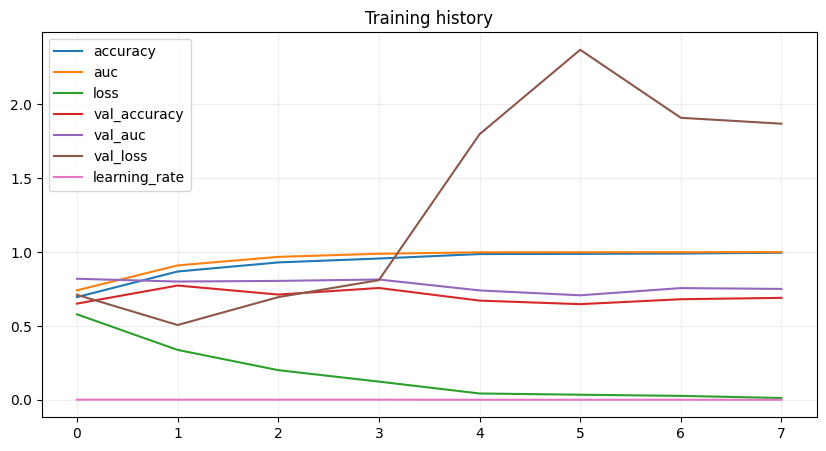

In [16]:
# ---------- Train ----------
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=PATIENCE,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5,
        patience=3, min_lr=1e-6
    )
]

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1,
    class_weight=None
)

pd.DataFrame(history.history).plot(figsize=(10,5), title="Training history")
plt.grid(alpha=.2)
plt.show()

## 4. EEGNet model

This section adds **EEGNet** as a second deep-learning model. It uses the **same preprocessed EEG windows, same subject-wise train/validation/test split, and same fixed channel representation** as the CNN + Transformer model.

The notebook now contains three predictive models:
1. **CNN + Transformer**
2. **EEGNet**
3. **PSD + XGBoost**

The final multimodel ensemble combines their probabilities using weights selected on the validation subjects only.


In [22]:
import os, re, json, math, shutil, zipfile, warnings, tempfile
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
from scipy import signal
import scipy.io as sio

from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, average_precision_score, confusion_matrix,
    matthews_corrcoef, classification_report, roc_curve, precision_recall_curve
)
from xgboost import XGBClassifier
import joblib

import matplotlib.pyplot as plt
import seaborn as sns
import mne

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

# ============================================================
# EEGNet architecture (corrected)
# Input shape: (time_samples, channels)
# Output: ADHD probability in [0, 1]
# ============================================================
def build_eegnet(input_shape, dropout_rate=0.5, F1=8, D=2, F2=16):
    inp = keras.Input(shape=input_shape, name="eeg_input") # (Time, Channels)

    # (batch, Time, Channels) -> (batch, Time, Channels, 1) for Conv2D compatibility
    x = layers.Reshape((input_shape[0], input_shape[1], 1))(inp) # (batch, Time, Channels, 1)

    # Block 1
    # Temporal filtering: Convolves across time for each channel.
    # Kernel (temporal_kernel_length, 1). Using 64 as filter length for time.
    x = layers.Conv2D(F1, (64, 1), padding="same", use_bias=False,
                      data_format="channels_last")(x) # Output: (batch, Time, Channels, F1)
    x = layers.BatchNormalization()(x)

    # Depthwise spatial filtering across EEG channels.
    # Kernel (1, number_of_channels). Operates on the Channels dimension.
    # `input_shape[1]` is the number of channels.
    # A (1, input_shape[1]) kernel with 'valid' padding will collapse the channel dimension.
    x = layers.DepthwiseConv2D(
        (1, input_shape[1]), # Kernel (1, Num_channels) covering all channels
        depth_multiplier=D,
        padding="valid", # This ensures the channel dimension becomes 1
        use_bias=False,
        data_format="channels_last"
    )(x) # Output: (batch, Time, 1, F1 * D)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)

    # AveragePooling2D: Pool along the time dimension.
    # Input is (batch, Time, 1, F1 * D). Pool size should be (pool_time_length, 1).
    x = layers.AveragePooling2D((4, 1), data_format="channels_last")(x) # Output: (batch, Time/4, 1, F1 * D)
    x = layers.Dropout(dropout_rate)(x)

    # Block 2: separable temporal filtering
    # SeparableConv2D: depthwise conv (temporal) followed by a pointwise conv.
    # The depthwise part uses a kernel `(temporal_kernel_length, 1)`
    # Input: (batch, Time/4, 1, F1 * D)
    x = layers.SeparableConv2D(
        F2, (16, 1), # (temporal_kernel_size, 1)
        padding="same",
        use_bias=False,
        data_format="channels_last"
    )(x) # Output: (batch, (Time/4), 1, F2)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("elu")(x)

    # AveragePooling2D: Pool along the time dimension.
    x = layers.AveragePooling2D((8, 1), data_format="channels_last")(x) # Output: (batch, ((Time/4)/8), 1, F2)
    x = layers.Dropout(dropout_rate)(x)

    x = layers.Flatten()(x)
    x = layers.Dense(64, activation="elu")(x)
    x = layers.Dropout(dropout_rate)(x)
    out = layers.Dense(1, activation="sigmoid", name="adhd_probability")(x)

    return keras.Model(inp, out, name="EEGNet")

eegnet = build_eegnet(X_train.shape[1:], dropout_rate=DROPOUT)
eegnet.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.BinaryAccuracy(name="accuracy"),
        keras.metrics.AUC(name="auc")
    ]
)
eegnet.summary()

TensorFlow: 2.20.0
GPU: []


Model: "EEGNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ eeg_input (InputLayer)          │ (None, 1280, 19)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape_1 (Reshape)             │ (None, 1280, 19, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 1280, 19, 8)    │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 1280, 19, 8)    │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ depthwise_conv2d_1              │ (None, 1280, 1, 16)    │           304 │
│ (DepthwiseConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 1280, 1, 16)    │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 1280, 1, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 320, 1, 16)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 320, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ separable_conv2d_1              │ (None, 320, 1, 16)     │           512 │
│ (SeparableConv2D)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 320, 1, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 320, 1, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 40, 1, 16)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 40, 1, 16)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ adhd_probability (Dense)        │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,577 (166.32 KB)

 Trainable params: 42,497 (166.00 KB)

 Non-trainable params: 80 (320.00 B)

Epoch 1/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.5769 - auc: 0.5740 - loss: 0.7168 - val_accuracy: 0.4416 - val_auc: 0.7049 - val_loss: 0.7082 - learning_rate: 0.0010
Epoch 2/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.7222 - auc: 0.7903 - loss: 0.5507 - val_accuracy: 0.4453 - val_auc: 0.7984 - val_loss: 0.7860 - learning_rate: 0.0010
Epoch 3/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.7847 - auc: 0.8510 - loss: 0.4640 - val_accuracy: 0.4657 - val_auc: 0.8112 - val_loss: 0.7617 - learning_rate: 0.0010
Epoch 4/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.8145 - auc: 0.8869 - loss: 0.4117 - val_accuracy: 0.5714 - val_auc: 0.8028 - val_loss: 0.6716 - learning_rate: 0.0010
Epoch 5/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 74s 1s/step - accuracy: 0.8557 - auc: 0.9234 - loss: 0.3423 - val_accuracy: 0.7069 - val_auc: 0.8193 - val_loss: 0.5534 - learning_rate: 0.0010
Epoch 6/35
63/63 ━━━━━━━━━━━━━━━━━━━━ 86s 1s/step - accuracy: 0.8889 - auc: 0.9548 - loss

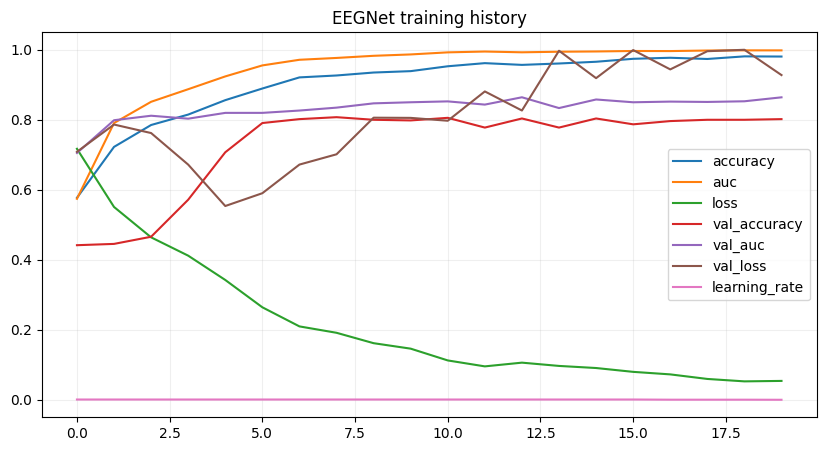

In [23]:
# ============================================================
# Train EEGNet
# ============================================================
eegnet_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_auc", mode="max", patience=PATIENCE,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_auc", mode="max", factor=0.5,
        patience=3, min_lr=1e-6
    )
]

history_eegnet = eegnet.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=eegnet_callbacks,
    verbose=1
)

pd.DataFrame(history_eegnet.history).plot(
    figsize=(10, 5), title="EEGNet training history"
)
plt.grid(alpha=.2)
plt.show()

## 5. PSD + XGBoost baseline

This is not the primary deep-learning model. It provides a classical comparison using delta/theta/alpha/beta/gamma relative power and simple time-domain summaries.

In [24]:
BANDS = {
    "delta": (1,4),
    "theta": (4,8),
    "alpha": (8,13),
    "beta": (13,30),
    "gamma": (30,45)
}

def psd_features(window, fs):
    freqs, psd = signal.welch(
        window, fs=fs, nperseg=min(256, len(window)), axis=0
    )
    psd = psd.T + 1e-12
    total_mask = (freqs >= 1) & (freqs < min(45, fs/2))
    total = np.trapezoid(psd[:, total_mask], freqs[total_mask], axis=1) + 1e-12

    feats = []
    for band, (lo, hi) in BANDS.items():
        hi = min(hi, fs/2 * 0.95)
        mask = (freqs >= lo) & (freqs < hi)
        if mask.sum() < 2:
            rel = np.zeros(psd.shape[0])
        else:
            bp = np.trapezoid(psd[:, mask], freqs[mask], axis=1)
            rel = bp / total
        feats.extend([rel.mean(), rel.std(), np.median(rel)])

    # Time-domain summaries
    for a in [np.sqrt(np.mean(window**2, axis=0)),
              np.std(window, axis=0),
              np.mean(np.abs(window), axis=0)]:
        feats.extend([a.mean(), a.std(), np.median(a)])

    return np.asarray(feats, dtype=np.float32)

def build_psd(subject_set):
    F, y, g = [], [], []
    for r in records:
        if r["subject"] not in subject_set:
            continue
        for w in r["windows"]:
            F.append(psd_features(w, r["fs"]))
            y.append(r["label"])
            g.append(r["subject"])
    return np.asarray(F), np.asarray(y), np.asarray(g)

F_train, fy_train, fg_train = build_psd(train_subjects)
F_val, fy_val, fg_val = build_psd(val_subjects)
F_test, fy_test, fg_test = build_psd(test_subjects)

scaler = StandardScaler()
F_train_s = scaler.fit_transform(F_train)
F_val_s = scaler.transform(F_val)
F_test_s = scaler.transform(F_test)

xgb = XGBClassifier(
    n_estimators=350, max_depth=4, learning_rate=0.03,
    subsample=.85, colsample_bytree=.85,
    reg_alpha=.1, reg_lambda=1.0,
    objective="binary:logistic", eval_metric="auc",
    random_state=SEED, n_jobs=-1
)
xgb.fit(F_train_s, fy_train, eval_set=[(F_val_s, fy_val)], verbose=False)
print("XGBoost trained.")

XGBoost trained.


## 6. Validation-only threshold tuning and subject-level prediction

This is important: the threshold is selected using **validation subjects**, not the test set. The test set remains untouched until final evaluation.

In [26]:
# ============================================================
# Subject-level aggregation + validation-only ensemble tuning
# ============================================================
def subject_probability(y, p, groups):
    df = pd.DataFrame({"y": y, "p": p, "subject": groups})
    return df.groupby("subject").agg(
        y=("y", "first"),
        probability=("p", "mean")
    )

def best_threshold(y, p):
    best_t, best_score = 0.5, -1
    for t in np.linspace(0.10, 0.90, 81):
        pred = (p >= t).astype(int)
        score = balanced_accuracy_score(y, pred)
        if score > best_score:
            best_score, best_t = score, float(t)
    return best_t, best_score

# Window-level probabilities on validation data
p_val_cnn = model.predict(X_val, batch_size=BATCH_SIZE, verbose=0).ravel()
p_val_eegnet = eegnet.predict(X_val, batch_size=BATCH_SIZE, verbose=0).ravel()
p_val_xgb = xgb.predict_proba(F_val_s)[:, 1]

# Convert all models to subject-level probabilities before tuning
sv_cnn = subject_probability(y_val, p_val_cnn, g_val)
sv_eegnet = subject_probability(y_val, p_val_eegnet, g_val)
sv_xgb = subject_probability(fy_val, p_val_xgb, fg_val)

common = sv_cnn.index.intersection(sv_eegnet.index).intersection(sv_xgb.index)
val_subject = pd.DataFrame({
    "y": sv_cnn.loc[common, "y"].values,
    "cnn_transformer": sv_cnn.loc[common, "probability"].values,
    "eegnet": sv_eegnet.loc[common, "probability"].values,
    "xgb": sv_xgb.loc[common, "probability"].values
}, index=common)

# Search weights on validation subjects only.
best_weights = None
best_t = 0.5
best_score = -np.inf

for w_cnn in np.linspace(0, 1, 21):
    for w_eegnet in np.linspace(0, 1 - w_cnn, 21):
        w_xgb = 1.0 - w_cnn - w_eegnet
        p = (
            w_cnn * val_subject["cnn_transformer"].values +
            w_eegnet * val_subject["eegnet"].values +
            w_xgb * val_subject["xgb"].values
        )
        t, score = best_threshold(val_subject["y"].values, p)
        if score > best_score:
            best_score = score
            best_weights = (float(w_cnn), float(w_eegnet), float(w_xgb))
            best_t = float(t)

print("Validation-selected weights:")
print("  CNN + Transformer:", best_weights[0])
print("  EEGNet:", best_weights[1])
print("  PSD + XGBoost:", best_weights[2])
print("Validation-selected threshold:", best_t)
print("Validation balanced accuracy:", best_score)


Validation-selected weights:
  CNN + Transformer: 0.0
  EEGNet: 0.15000000000000002
  PSD + XGBoost: 0.85
Validation-selected threshold: 0.59
Validation balanced accuracy: 0.898989898989899


,Model,Accuracy,Balanced Accuracy,Precision,Recall/Sensitivity,Specificity,F1,ROC-AUC,PR-AUC,MCC
0,CNN + Transformer,0.5833,0.5833,0.5455,1.0000,0.1667,0.7059,0.7361,0.6475,0.3015
1,EEGNet,0.7500,0.7500,0.7143,0.8333,0.6667,0.7692,0.7222,0.6461,0.5071
2,PSD + XGBoost,0.5417,0.5417,0.5455,0.5000,0.5833,0.5217,0.6458,0.6377,0.0836
3,3-Model Ensemble,0.5833,0.5833,0.5833,0.5833,0.5833,0.5833,0.6944,0.6764,0.1667


              precision    recall  f1-score   support

     Control     0.5833    0.5833    0.5833        12
        ADHD     0.5833    0.5833    0.5833        12

    accuracy                         0.5833        24
   macro avg     0.5833    0.5833    0.5833        24
weighted avg     0.5833    0.5833    0.5833        24



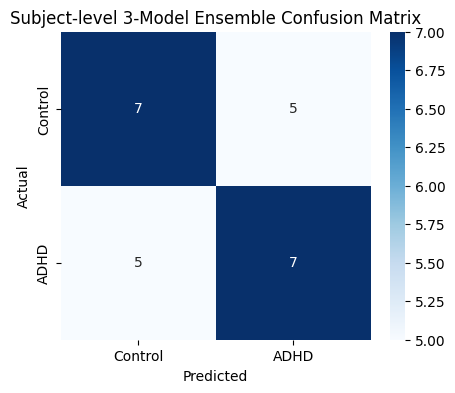

In [27]:
# ============================================================
# Final untouched test evaluation
# ============================================================
p_test_cnn = model.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
p_test_eegnet = eegnet.predict(X_test, batch_size=BATCH_SIZE, verbose=0).ravel()
p_test_xgb = xgb.predict_proba(F_test_s)[:, 1]

st_cnn = subject_probability(y_test, p_test_cnn, g_test)
st_eegnet = subject_probability(y_test, p_test_eegnet, g_test)
st_xgb = subject_probability(fy_test, p_test_xgb, fg_test)

common = st_cnn.index.intersection(st_eegnet.index).intersection(st_xgb.index)
test_subject = pd.DataFrame({
    "y": st_cnn.loc[common, "y"].values,
    "cnn_transformer": st_cnn.loc[common, "probability"].values,
    "eegnet": st_eegnet.loc[common, "probability"].values,
    "xgb": st_xgb.loc[common, "probability"].values
}, index=common)

w_cnn, w_eegnet, w_xgb = best_weights
test_subject["ensemble"] = (
    w_cnn * test_subject["cnn_transformer"] +
    w_eegnet * test_subject["eegnet"] +
    w_xgb * test_subject["xgb"]
)

def metric_row(name, y, p, threshold):
    pred = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0,1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) else 0
    return {
        "Model": name,
        "Accuracy": accuracy_score(y, pred),
        "Balanced Accuracy": balanced_accuracy_score(y, pred),
        "Precision": precision_score(y, pred, zero_division=0),
        "Recall/Sensitivity": recall_score(y, pred, zero_division=0),
        "Specificity": spec,
        "F1": f1_score(y, pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y, p) if len(np.unique(y)) == 2 else np.nan,
        "PR-AUC": average_precision_score(y, p) if len(np.unique(y)) == 2 else np.nan,
        "MCC": matthews_corrcoef(y, pred)
    }

results = pd.DataFrame([
    metric_row("CNN + Transformer", test_subject.y, test_subject.cnn_transformer, best_t),
    metric_row("EEGNet", test_subject.y, test_subject.eegnet, best_t),
    metric_row("PSD + XGBoost", test_subject.y, test_subject.xgb, best_t),
    metric_row("3-Model Ensemble", test_subject.y, test_subject.ensemble, best_t)
])

display(results.style.format({c: "{:.4f}" for c in results.columns if c != "Model"}))

pred = (test_subject.ensemble >= best_t).astype(int)
print(classification_report(
    test_subject.y, pred,
    target_names=[CLASS_NAMES[0], CLASS_NAMES[1]],
    digits=4
))

cm = confusion_matrix(test_subject.y, pred, labels=[0,1])
plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]],
    yticklabels=[CLASS_NAMES[0], CLASS_NAMES[1]]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Subject-level 3-Model Ensemble Confusion Matrix")
plt.show()


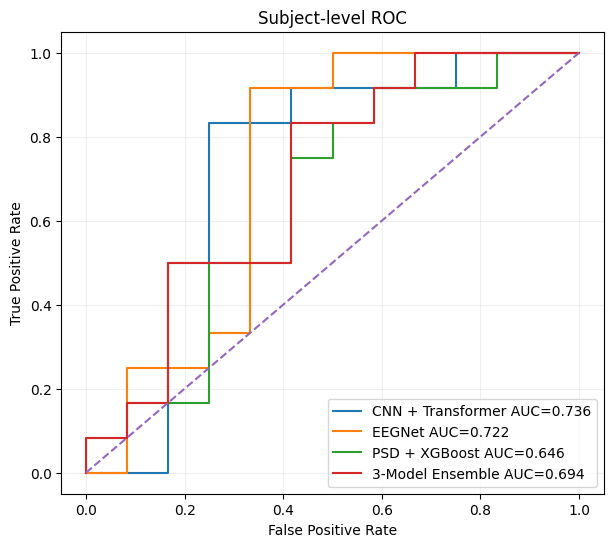

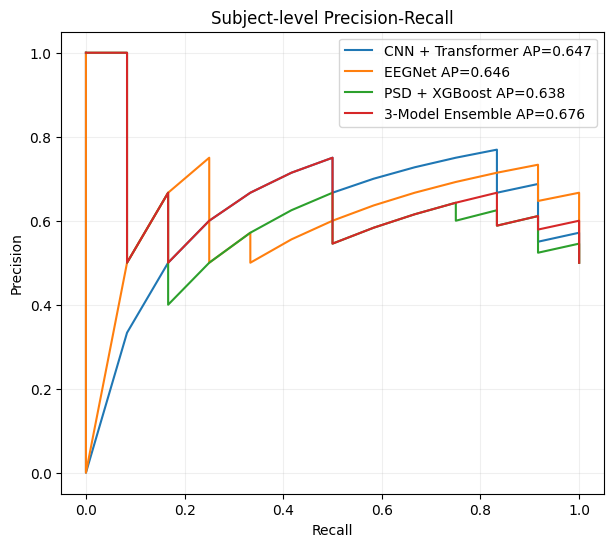

In [28]:
# ============================================================
# ROC and Precision-Recall curves
# ============================================================
plt.figure(figsize=(7,6))
for name, p in [
    ("CNN + Transformer", test_subject.cnn_transformer),
    ("EEGNet", test_subject.eegnet),
    ("PSD + XGBoost", test_subject.xgb),
    ("3-Model Ensemble", test_subject.ensemble)
]:
    fpr, tpr, _ = roc_curve(test_subject.y, p)
    auc = roc_auc_score(test_subject.y, p)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.3f}")
plt.plot([0,1], [0,1], "--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Subject-level ROC")
plt.legend()
plt.grid(alpha=.2)
plt.show()

plt.figure(figsize=(7,6))
for name, p in [
    ("CNN + Transformer", test_subject.cnn_transformer),
    ("EEGNet", test_subject.eegnet),
    ("PSD + XGBoost", test_subject.xgb),
    ("3-Model Ensemble", test_subject.ensemble)
]:
    precision, recall, _ = precision_recall_curve(test_subject.y, p)
    ap = average_precision_score(test_subject.y, p)
    plt.plot(recall, precision, label=f"{name} AP={ap:.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Subject-level Precision-Recall")
plt.legend()
plt.grid(alpha=.2)
plt.show()


## 7. Predict a new EEG recording

Use this cell only after training. The new recording must have a known or explicitly provided sampling rate and must be compatible with the signal format.

**Important:** if the model was trained on one dataset, it is not automatically valid for a completely different EEG dataset. For a new dataset/domain, retraining or external validation is required.

In [29]:
def predict_one_file(path, label_if_known=None):
    """Predict one new EEG recording with all three models + ensemble."""
    path = Path(path)
    arr, ch_names, fs, info = read_recording(path)
    arr = orient_time_channels(arr, ch_names)

    if fs is None:
        fs = DEFAULT_FS
    if fs is None:
        raise ValueError("Sampling rate is missing. Set DEFAULT_FS.")

    arr, fs = resample_signal(arr, float(fs), TARGET_FS)
    arr = preprocess_signal(arr, fs)
    windows = make_windows(arr, fs)
    if not windows:
        raise ValueError("Recording is too short for one complete window.")

    X = np.asarray(windows, dtype=np.float32)
    X = pad_channels(X, MAX_CHANNELS)

    p_cnn = model.predict(X, batch_size=BATCH_SIZE, verbose=0).ravel().mean()
    p_eegnet = eegnet.predict(X, batch_size=BATCH_SIZE, verbose=0).ravel().mean()

    F = np.asarray([psd_features(w, fs) for w in windows])
    p_xgb = xgb.predict_proba(scaler.transform(F))[:, 1].mean()

    w_cnn, w_eegnet, w_xgb = best_weights
    p_ensemble = (
        w_cnn * p_cnn +
        w_eegnet * p_eegnet +
        w_xgb * p_xgb
    )
    pred = int(p_ensemble >= best_t)

    return {
        "file": str(path),
        "prediction": CLASS_NAMES[pred],
        "class_id": pred,
        "probability_ADHD": float(p_ensemble),
        "cnn_transformer_probability": float(p_cnn),
        "eegnet_probability": float(p_eegnet),
        "xgboost_probability": float(p_xgb),
        "ensemble_weights": {
            "cnn_transformer": float(w_cnn),
            "eegnet": float(w_eegnet),
            "xgboost": float(w_xgb)
        },
        "threshold": float(best_t),
        "windows_used": len(windows)
    }

# Example:
# new_uploaded = files.upload()
# new_file = Path("/content") / next(iter(new_uploaded.keys()))
# print(predict_one_file(new_file))


In [30]:
# ============================================================
# Save all trained models and ensemble configuration
# ============================================================
OUTPUT_DIR.mkdir(exist_ok=True)
model.save(OUTPUT_DIR / "cnn_transformer.keras")
eegnet.save(OUTPUT_DIR / "eegnet.keras")
xgb.save_model(OUTPUT_DIR / "xgboost.json")
joblib.dump(scaler, OUTPUT_DIR / "psd_scaler.joblib")

ensemble_config = {
    "models": ["CNN + Transformer", "EEGNet", "PSD + XGBoost"],
    "weights": {
        "cnn_transformer": float(best_weights[0]),
        "eegnet": float(best_weights[1]),
        "xgboost": float(best_weights[2])
    },
    "threshold": float(best_t),
    "target_fs": float(TARGET_FS),
    "max_channels": int(MAX_CHANNELS),
    "class_names": {"0": "Control", "1": "ADHD"}
}

with open(OUTPUT_DIR / "ensemble_config.json", "w") as f:
    json.dump(ensemble_config, f, indent=2)

print("Saved:")
print(OUTPUT_DIR / "cnn_transformer.keras")
print(OUTPUT_DIR / "eegnet.keras")
print(OUTPUT_DIR / "xgboost.json")
print(OUTPUT_DIR / "psd_scaler.joblib")
print(OUTPUT_DIR / "ensemble_config.json")


Saved:
/content/eeg_adhd_model_package/cnn_transformer.keras
/content/eeg_adhd_model_package/eegnet.keras
/content/eeg_adhd_model_package/xgboost.json
/content/eeg_adhd_model_package/psd_scaler.joblib
/content/eeg_adhd_model_package/ensemble_config.json


# Why this version is safer

1. **It does not hard-code 19 channels.**
2. It supports several common EEG formats.
3. It uses metadata when available.
4. It does not silently guess missing labels.
5. It uses **subject-wise** train/validation/test splits.
6. It tunes the decision threshold using validation data only.
7. Final test metrics are calculated only once on unseen subjects.
8. It evaluates at the **subject level**, not by pretending every overlapping EEG window is an independent person.
9. It reports the confusion matrix and multiple metrics instead of showing only accuracy.
10. It explicitly warns that a model cannot guarantee correct predictions on a new dataset.

### If another dataset is rejected

Look at the **dataset inspector** and **failed recordings** table. Usually the reason is one of:
- label names are different (`ADHD_group`, `TD`, `patient`, etc.),
- sampling rate is absent,
- the MAT file stores EEG inside an unusual structure,
- the CSV contains non-signal columns,
- the dataset has more than two classes,
- there is no reliable subject ID,
- the file is not actually an EEG recording.

In those cases, change only the corresponding configuration/reader instead of changing the model blindly.

## Multimodel architecture

```text
Preprocessed EEG windows
        |
        +-------------------+-------------------+
        |                   |                   |
 CNN + Transformer       EEGNet          PSD features
        |                   |                   |
        |                   |              XGBoost
        +-------------------+-------------------+
                            |
                 Validation-tuned ensemble
                            |
                   Subject-level prediction
```
